# 4. Orbits and insolation

A `System` links worlds together gravitationally: a host body (often also the star) and one or more
worlds orbiting it, each with its own orbital elements. This demo builds a star and a planet, reads
the orbital frequency the system computes from the masses and separation, and then looks at how much
starlight the planet receives and the equilibrium temperature that follows, across different stellar
types and orbital distances.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.system import System
from TidalPy.structures_x.worlds.stellar import StarWorld
from TidalPy.structures_x.configs import build_world

AU = 1.495978707e11     # metres
YEAR = 3.15576e7        # seconds

star = StarWorld("Sun", 6.957e8, 1.988e30)
star.set_effective_temperature(5772.0)
planet = build_world("earth_simple")

system = System("Star-Planet")
system.add_world(star, is_host=True, is_star=True)
system.add_world(planet, semi_major_axis=AU, eccentricity=0.0167)

# A system tracks a world's distance from its tidal *host* and from the *star* separately, because a
# moon can orbit a planet that is not itself the star. Here the star is the host, so the two are equal.
system.set_stellar_semi_major_axis(planet, AU)

print("worlds:", [w.name for w in system])
print("host  :", system.host.name, "| star:", system.star.name)


worlds: ['Sun', 'Earth-Simple']
host  : Sun | star: Sun


## Orbital frequency

Given the two masses and the separation, the system computes the orbital (mean-motion) frequency from Kepler's third law. We check it against the closed-form value and convert it to an orbital period.

In [2]:
n = system.calc_orbital_frequency(planet)
n_kepler = np.sqrt(G * (star.mass + planet.mass) / AU**3)
period_days = 2.0 * np.pi / n / 86400.0

print(f"orbital frequency (system) : {n:.6e} rad/s")
print(f"orbital frequency (Kepler) : {n_kepler:.6e} rad/s")
print(f"orbital period             : {period_days:.2f} days  ({period_days/365.25:.3f} yr)")


orbital frequency (system) : 1.990781e-07 rad/s
orbital frequency (Kepler) : 1.990781e-07 rad/s
orbital period             : 365.29 days  (1.000 yr)


## Insolation and equilibrium temperature

The star's luminosity sets the flux reaching the planet, which falls off as the inverse square of distance. The planet turns that flux, together with its albedo, into an equilibrium temperature. At 1 AU from the Sun this reproduces the solar constant and Earth's roughly 255 K equilibrium temperature.

In [3]:
flux = system.calc_insolation_flux(planet)
t_eq = system.calc_equilibrium_temperature(planet)
print(f"insolation flux at 1 AU    : {flux:.1f} W/m^2  (the solar constant)")
print(f"equilibrium temperature    : {t_eq:.1f} K")


insolation flux at 1 AU    : 1361.2 W/m^2  (the solar constant)
equilibrium temperature    : 254.6 K


## Across stellar types and distances

The same physics scales to any star. Here we take five representative main-sequence types, each with a
characteristic effective temperature and radius (which together fix its luminosity), and trace the
planet's equilibrium temperature as a function of orbital distance. The shaded band marks liquid-water
temperatures (273 to 373 K): where it crosses each curve is a rough habitable zone. Hotter, more
luminous stars push that zone outward.


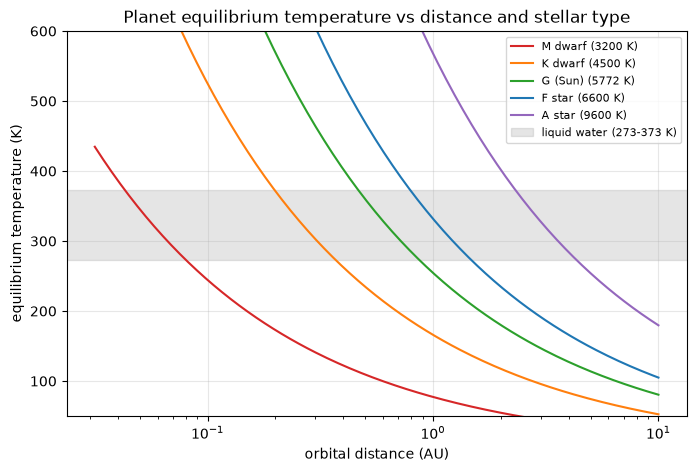

In [4]:
R_sun = 6.957e8
stellar_types = [
    ("M dwarf", 3200.0, 0.30 * R_sun, "tab:red"),
    ("K dwarf", 4500.0, 0.70 * R_sun, "tab:orange"),
    ("G (Sun)", 5772.0, 1.00 * R_sun, "tab:green"),
    ("F star",  6600.0, 1.30 * R_sun, "tab:blue"),
    ("A star",  9600.0, 1.80 * R_sun, "tab:purple"),
]

distances = np.logspace(-1.5, 1.0, 200) * AU   # 0.03 to 10 AU

fig, ax = plt.subplots(figsize=(8, 5))
for label, teff, radius, color in stellar_types:
    s = StarWorld(label, radius, 1.0e30)
    s.set_effective_temperature(teff)
    flux = s.luminosity / (4.0 * np.pi * distances**2)
    t_eq = np.array([planet.calc_equilibrium_temperature(f) for f in flux])
    ax.plot(distances / AU, t_eq, color=color, label=f"{label} ({teff:.0f} K)")

ax.axhspan(273.0, 373.0, color="gray", alpha=0.2, label="liquid water (273-373 K)")
ax.set_xscale("log")
ax.set_xlabel("orbital distance (AU)")
ax.set_ylabel("equilibrium temperature (K)")
ax.set_ylim(50, 600)
ax.set_title("Planet equilibrium temperature vs distance and stellar type")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()


## Recap

- A `System` links a host, a star, and orbiting worlds; `add_world` sets each world's role and orbital
  elements.
- `calc_orbital_frequency` returns the Kepler mean motion from the masses and separation.
- `calc_insolation_flux` and `calc_equilibrium_temperature` give the starlight a world receives and the
  temperature that follows. Both scale with the star's luminosity and the inverse square of distance.

Next: **`05_tidal_basics`** attaches a tide model and computes tidal heating.
